In [28]:
import numpy as np
import pandas as pd
import arviz as az
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from cmdstanpy import CmdStanModel
from sampler import CycloneDataSimulator, SimplifiedDataSimulator

In [29]:
# test some prior parameters that I got from Claude:
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 2               # number of ocean basins
D = 5               # number of predictors
N = 2000             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [30]:
# compile Stan model
model = CmdStanModel(stan_file="conjugate_model.stan")

In [31]:
# fit and sample using Stan model
fit = model.sample(stan_data)
draws_df = fit.draws_pd()

16:57:10 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   5%|▌         | 100/2000 [00:14<04:30,  7.02it/s, (Warmup)]

chain 1:  15%|█▌        | 300/2000 [00:25<02:04, 13.64it/s, (Warmup)]





chain 1:  25%|██▌       | 500/2000 [00:34<01:26, 17.43it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:38<01:14, 18.73it/s, (Warmup)]





chain 1:  35%|███▌      | 700/2000 [00:45<01:15, 17.27it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:49<01:01, 19.65it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:52<00:50, 21.67it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:57<00:46, 21.56it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [01:02<00:43, 20.83it/s, (Sampling)]


16:58:17 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error -2
16:58:17 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error -2
16:58:17 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown er

KeyboardInterrupt: 

chain 1:  55%|█████▌    | 1100/2000 [01:17<00:43, 20.83it/s, (Sampling)]




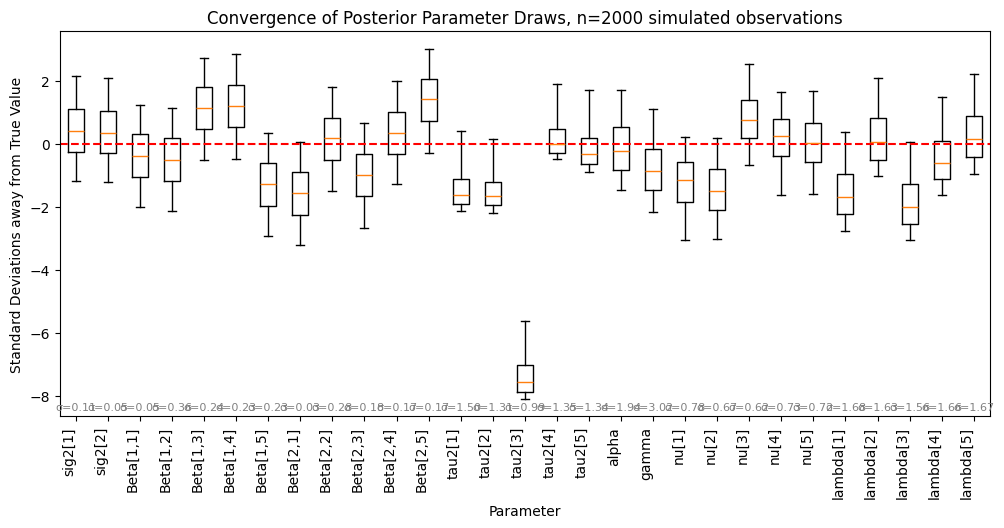

In [ ]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.5f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

Look at prior to posterior reduction in variance vs sample size.

Try fewer observations to test sensitivity to sample size.

In [ ]:
# hyperprior parameters
a = 1000
y_alpha = 1000
z_alpha = 50
y_gamma = 1000
z_gamma = 50 
v2 = 100
y_lam = 1000
z_lam = 50

# test some prior parameters that I got from Claude:
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 2               # number of ocean basins
D = 5               # number of predictors
N = 100             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

# fit and sample using Stan model
fit = model.sample(stan_data)
draws_df = fit.draws_pd()

14:55:44 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]







chain 1:   5%|▌         | 100/2000 [00:00<00:03, 521.42it/s, (Warmup)]

chain 1:  10%|█         | 200/2000 [00:00<00:04, 437.11it/s, (Warmup)]



chain 1:  15%|█▌        | 300/2000 [00:00<00:04, 424.75it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:00<00:03, 489.17it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:01<00:03, 495.94it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:01<00:02, 498.54it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:01<00:02, 534.79it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:01<00:02, 589.29it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:01<00:01, 634.22it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [00:01<00:01, 642.25it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:02<00:01, 585.73it/s, (Sampling)]




chain 1:  60%|██████    | 1200/2000 [00:02<00:01, 554.71it/s, (Sampling)]



chain 1:  65%|██████▌   | 1300/2000 [00:02<00:01, 543.64it/s, (Sampling)]


chain 1:  70%|███████   | 1


14:55:48 - cmdstanpy - INFO - CmdStan done processing.
14:55:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


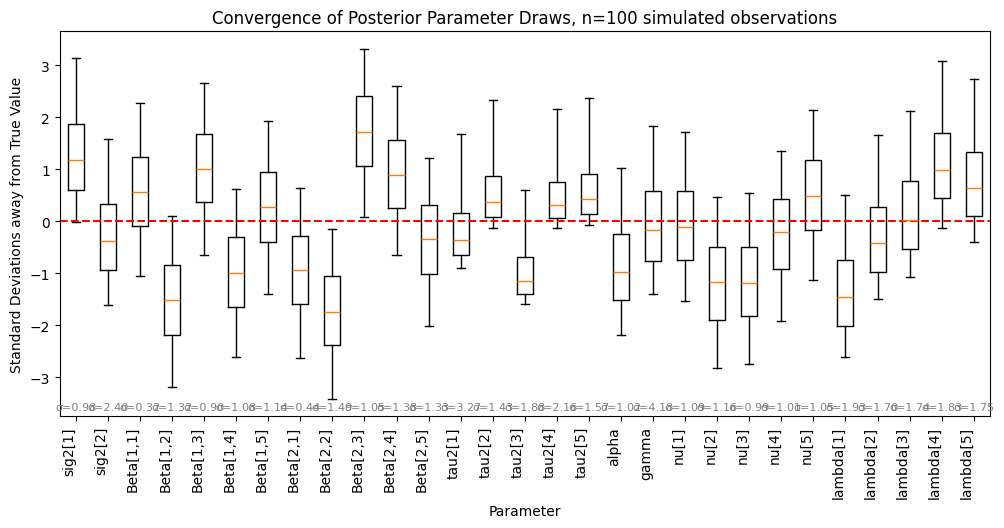

In [ ]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.5f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

Test the simplified model.

In [ ]:
# test some prior parameters that I got from Claude:
a_sig = 3
b_sig = 0.2
a_tau = 3
b_tau = 0.1 
v2 = 0.25

# model parameters
B = 2               # number of ocean basins
D = 5               # number of predictors
N = 5000             # number of observations

# simulate N observations from the model
DataSimulator = SimplifiedDataSimulator(
    B = B,
    a_sig=a_sig, b_sig=b_sig,
    v2=v2,
    a_tau=a_tau, b_tau=b_tau,
    standardize=False
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# try standarxizing X before fitting
# X = (X - X.mean(axis=0)) / X.std(axis=0)


# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.nu,
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a_sig" : a_sig, "b_sig" : b_sig,
    "v2" : v2,
    "a_tau" : a_tau, "b_tau" : b_tau,
}

In [ ]:
# compile the stan model
simple_model = CmdStanModel(stan_file="simplified_model.stan")

In [ ]:
# fit and sample using Stan model
fit = simple_model.sample(stan_data, iter_warmup=1000, iter_sampling=5000, chains=4)
draws_df = fit.draws_pd()

14:55:49 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/6000 [00:00<?, ?it/s, (Warmup)]


chain 1:   2%|▏         | 100/6000 [00:16<16:34,  5.93it/s, (Warmup)]


chain 1:   3%|▎         | 200/6000 [00:27<12:40,  7.63it/s, (Warmup)]


chain 1:   7%|▋         | 400/6000 [00:37<07:04, 13.21it/s, (Warmup)]


chain 1:   8%|▊         | 500/6000 [00:42<06:06, 14.99it/s, (Warmup)]


chain 1:  10%|█         | 600/6000 [00:47<05:28, 16.42it/s, (Warmup)]


chain 1:  12%|█▏        | 700/6000 [00:51<04:49, 18.34it/s, (Warmup)]


chain 1:  13%|█▎        | 800/6000 [00:55<04:22, 19.79it/s, (Warmup)]


chain 1:  15%|█▌        | 900/6000 [01:02<04:47, 17.73it/s, (Warmup)]


chain 1:  17%|█▋        | 1000/6000 [01:08<04:40, 17.84it/s, (Sampling)]




chain 1:  18%|█▊        | 1100/6000 [01:13<04:31, 18.04it/s, (Sampling)]




chain 1:  20%|██        | 1200/6000 [01:18<04:23, 18.20it/s, (Sampling)]


chain 1:  22%|██▏       | 1300/6000 [01:24<04:15, 18.42it/s, (Sampling)]


cha

KeyboardInterrupt: 




chain 1:  53%|█████▎    | 3200/6000 [03:37<03:19, 14.00it/s, (Sampling)]

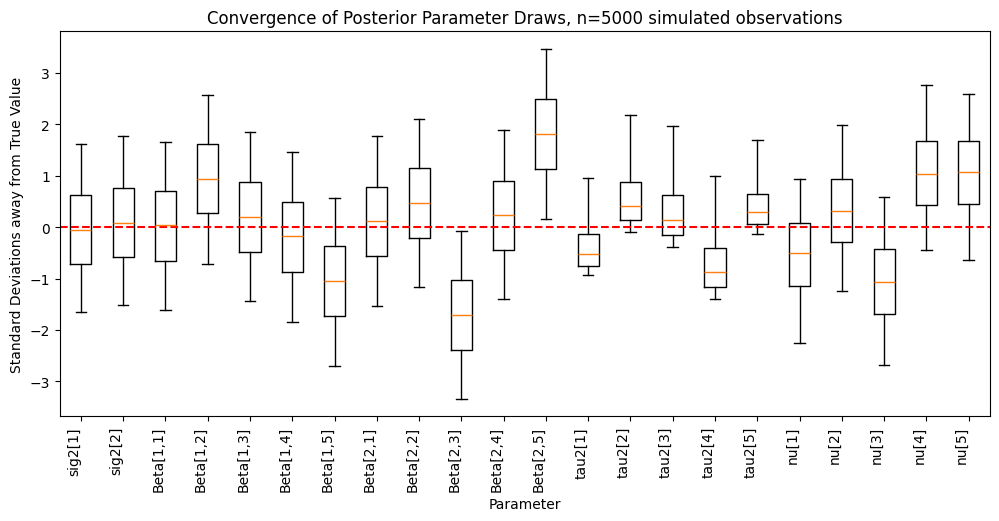

In [ ]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + [f"nu[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.5f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

Try only one basin

In [ ]:
# test some prior parameters that I got from Claude:
a_sig = 3
b_sig = 0.2
a_tau = 3
b_tau = 0.1 
v2 = 0.25

# model parameters
B = 1               # number of ocean basins
D = 5               # number of predictors
N = 500             # number of observations

# simulate N observations from the model
DataSimulator = SimplifiedDataSimulator(
    B = B,
    a_sig=a_sig, b_sig=b_sig,
    v2=v2,
    a_tau=a_tau, b_tau=b_tau,
    standardize=False
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# try standarxizing X before fitting
# X = (X - X.mean(axis=0)) / X.std(axis=0)


# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.nu,
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a_sig" : a_sig, "b_sig" : b_sig,
    "v2" : v2,
    "a_tau" : a_tau, "b_tau" : b_tau,
}

# fit and sample using Stan model
fit = simple_model.sample(stan_data, iter_warmup=1000, iter_sampling=5000, chains=4)
draws_df = fit.draws_pd()

16:34:29 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/6000 [00:00<?, ?it/s, (Warmup)]





chain 1:   2%|▏         | 100/6000 [00:03<03:04, 31.93it/s, (Warmup)]


chain 1:   3%|▎         | 200/6000 [00:03<01:39, 58.17it/s, (Warmup)]





chain 1:   7%|▋         | 400/6000 [00:05<00:53, 105.58it/s, (Warmup)]





chain 1:   8%|▊         | 500/6000 [00:05<00:47, 115.38it/s, (Warmup)]


chain 1:  10%|█         | 600/6000 [00:06<00:40, 132.74it/s, (Warmup)]


chain 1:  12%|█▏        | 700/6000 [00:06<00:34, 153.83it/s, (Warmup)]


chain 1:  13%|█▎        | 800/6000 [00:07<00:30, 171.25it/s, (Warmup)]





chain 1:  15%|█▌        | 900/6000 [00:07<00:28, 179.20it/s, (Warmup)]

chain 1:  17%|█▋        | 1000/6000 [00:08<00:28, 178.53it/s, (Sampling)]


chain 1:  20%|██        | 1200/6000 [00:09<00:27, 175.09it/s, (Sampling)]


chain 1:  22%|██▏       | 1300/6000 [00:10<00:28, 162.52it/s, (Sampling)]


chain 1:  23%|██▎       | 1400/6000 [00:10<00:28, 163.25it/s, 


16:35:17 - cmdstanpy - INFO - CmdStan done processing.
16:35:17 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'simplified_model.stan', line 37, column 4 to column 39)
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'simplified_model.stan', line 37, column 4 to column 39)
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'simplified_model.stan', line 37, column 4 to column 39)
Consider re-running with show_console=True if the above output is unclear!


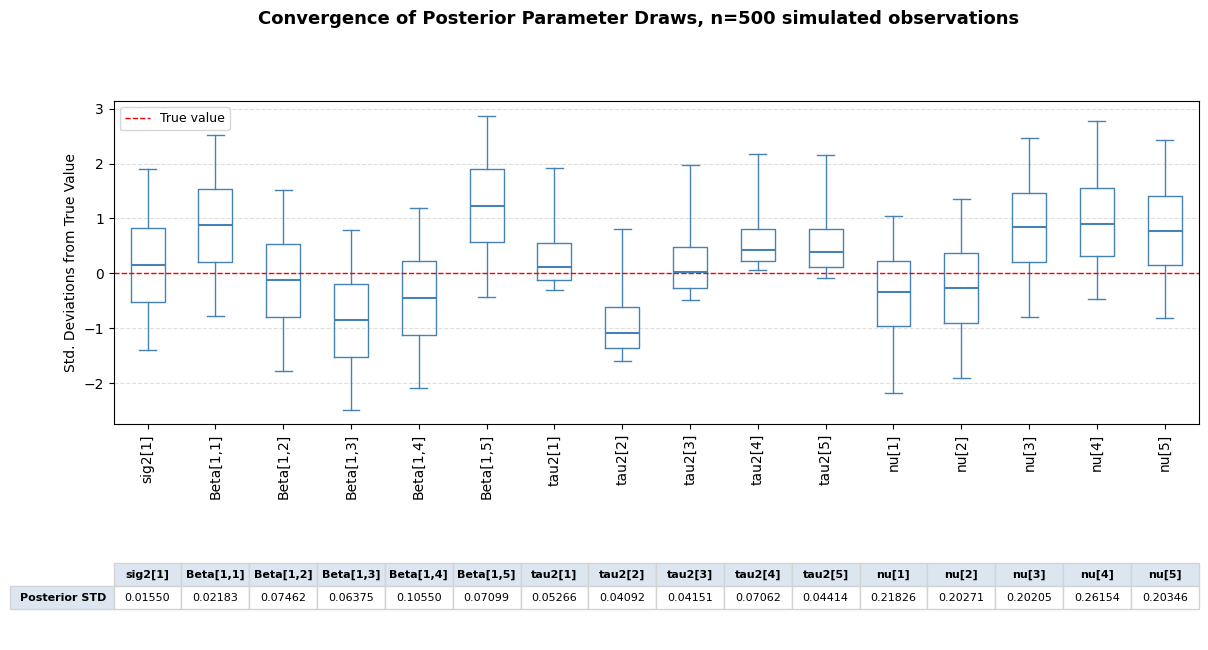

In [ ]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + [f"nu[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.5f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

ValueError: Incorrect use of keyword argument 'rotation'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

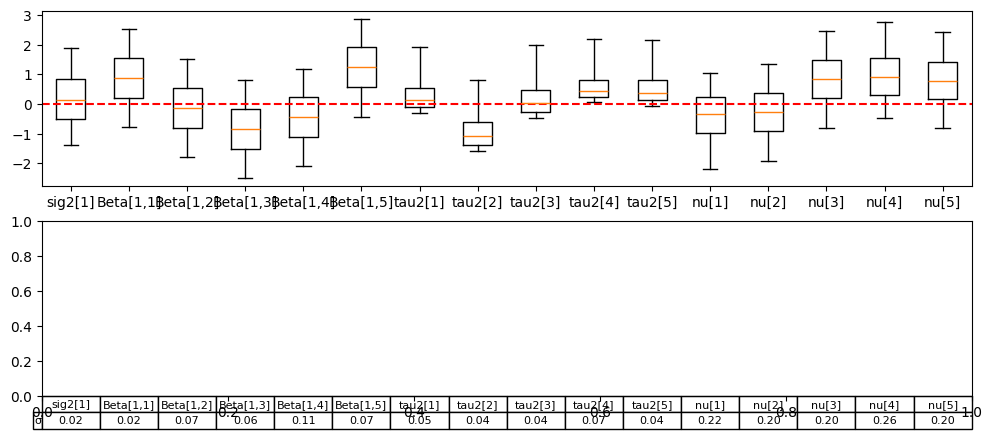

In [ ]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + [f"nu[{d}]" for d in range(1, D+1)]
true_params = np.concatenate([np.atleast_1d(p).flatten() for p in real_params])

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())


fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(211)
ax.boxplot(all_param_draws, 
            tick_labels=param_names, 
            whis=(5, 95), 
            showfliers=False, )

ax_table = fig.add_subplot(212)

table = ax_table.table(
    cellText=[[f'{s:.2f}' for s in param_stds]],   # wrap in outer list, format as strings
    colLabels=param_names,
    rowLabels=['σ'],
    loc='bottom',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)

ax.axhline(0, color='red', linestyle='--')
ax.set_xticks(param_names, rotation=90, ha='right')
ax.set_xlabel("Parameter")
ax.set_ylabel("Standard Deviations away from True Value")
plt.title(f"Convergence of Posterior Parameter Draws, n={N} simulated observations")
plt.show()